# Notebook 5 — PD-Based Approval Policy & Portfolio Simulation

**Goal:** Turn PD scores into approval decisions. Simulate portfolio outcomes under different risk appetites and compare **PD-threshold policies** against the earlier **grade-based policies**.

---

## Assumptions
- PD scores come from `loan_pd_predictions` (Notebook 4)
- Evaluation uses the **test set only** (`set_name='test'`) to avoid look-ahead bias
- Expected defaults: `E[defaults] = SUM(PD)`
- Expected loss proxy: `E[loss] = SUM(EAD * LGD * PD)` with **LGD = 90%** (simple v1)

In [1]:
# Imports
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


## 1) Connect to SQLite and build the scoring base
We join PD predictions to the corresponding loan records so we can simulate policies.


In [9]:
PROJECT_ROOT = Path.cwd().resolve()
DB_PATH = PROJECT_ROOT / "data" / "db" / "credit_risk.db"
assert DB_PATH.exists(), f"Database not found at: {DB_PATH}"

con = sqlite3.connect(DB_PATH)

# Confirm PD table exists
con.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='loan_pd_predictions';").fetchone()

('loan_pd_predictions',)

In [10]:
con.execute("CREATE INDEX IF NOT EXISTS idx_clean_loans_row_id ON clean_loans(row_id);")
con.execute("CREATE INDEX IF NOT EXISTS idx_pd_row_id ON loan_pd_predictions(row_id);")
con.execute("CREATE INDEX IF NOT EXISTS idx_pd_set_name ON loan_pd_predictions(set_name);")
con.commit()

In [12]:
query = """
SELECT
  p.row_id,
  p.id,
  p.issue_date AS issue_date_scored,
  p.pd_pred,
  c.grade,
  c.sub_grade,
  c.addr_state,
  c.purpose,
  c.term_months,
  c.int_rate_pct,
  c.installment,
  c.emp_length_yrs,
  c.home_ownership,
  c.annual_inc,
  c.verification_status,
  c.dti,
  c.delinq_2yrs,
  c.inq_last_6mths,
  c.open_acc,
  c.pub_rec,
  c.revol_bal,
  c.revol_util_pct,
  c.total_acc,
  c.fico_avg,
  c.loan_amnt AS exposure,
  c.loan_status,
  CASE
    WHEN c.loan_status IN ('Charged Off', 'Default') THEN 1
    WHEN c.loan_status = 'Fully Paid' THEN 0
    ELSE NULL
  END AS is_default
FROM loan_pd_predictions p
JOIN clean_loans c
  ON c.row_id = p.row_id
WHERE p.set_name = 'test'
"""


In [13]:
pd.read_sql_query(query + "\nLIMIT 5;", con)

,row_id,id,issue_date_scored,pd_pred,grade,sub_grade,addr_state,purpose,term_months,int_rate_pct,installment,emp_length_yrs,home_ownership,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util_pct,total_acc,fico_avg,exposure,loan_status,is_default
0,421185,130373788,2018-03-01 00:00:00,0.366428,D,D2,MO,debt_consolidation,60,18.45,487.14,10,MORTGAGE,50000.0,Source Verified,17.76,2,3,11,0,16449.0,36.6,29,692.0,19000.0,Charged Off,1
1,421193,130958175,2018-03-01 00:00:00,0.114358,B,B4,CA,debt_consolidation,36,10.90,555.76,10,OWN,70000.0,Source Verified,22.05,0,0,6,0,23119.0,61.2,9,712.0,17000.0,Charged Off,1
2,421256,130927766,2018-03-01 00:00:00,0.292955,D,D4,NJ,car,36,20.39,538.03,4,RENT,62400.0,Verified,34.17,0,0,9,0,22969.0,78.9,16,707.0,14400.0,Charged Off,1
3,421259,130961270,2018-03-01 00:00:00,0.121790,B,B5,AZ,debt_consolidation,36,11.98,498.08,3,RENT,30000.0,Not Verified,5.68,0,0,6,0,8511.0,35.9,9,702.0,15000.0,Charged Off,1
4,421281,130953722,2018-03-01 00:00:00,0.178934,C,C4,NV,debt_consolidation,36,15.04,485.59,2,RENT,31000.0,Not Verified,15.64,0,0,8,0,12319.0,75.6,17,687.0,14000.0,Charged Off,1


In [14]:
query_slim = """
SELECT
  p.row_id,
  p.pd_pred,
  c.grade,
  c.int_rate_pct,
  c.loan_amnt AS exposure,
  CASE
    WHEN c.loan_status IN ('Charged Off', 'Default') THEN 1
    WHEN c.loan_status = 'Fully Paid' THEN 0
    ELSE NULL
  END AS is_default
FROM loan_pd_predictions p
JOIN clean_loans c
  ON c.row_id = p.row_id
WHERE p.set_name = 'test';
"""
scored = pd.read_sql_query(query_slim, con)
scored.shape

(518744, 6)

### Sanity checks
- Row count should equal test set size
- PD mean should be plausible


In [15]:
scored["is_default"].value_counts(dropna=False), (scored["is_default"].mean() * 100).round(3)

(is_default
 0    402449
 1    116295
 Name: count, dtype: int64,
 np.float64(22.419))

## 2) PD threshold curve (test set)
We simulate a grid of PD cut-offs and measure:
- approval rate
- expected defaults (sum PD)
- realised default rate among approved loans
- expected loss proxy using a simple LGD assumption


In [26]:
LGD = 0.90  # simple v1 assumption
thresholds = np.round(np.linspace(0.02, 0.40, 20), 3)  # 2% to 40%

rows = []
for t in thresholds:
    approved = scored[scored["pd_pred"] < t].copy()
    if len(approved) == 0:
        continue

    approved_exposure = approved["exposure"].sum()
    exp_defaults = approved["pd_pred"].sum()
    exp_default_rate = approved["pd_pred"].mean()

    realised_default_rate = approved["is_default"].mean()
    realised_defaults = approved["is_default"].sum()

    exp_loss = (approved["exposure"] * LGD * approved["pd_pred"]).sum()

    rows.append({
        "pd_threshold": t,
        "approved_loans": len(approved),
        "approval_rate": len(approved) / len(scored),
        "approved_exposure": approved_exposure,
        "avg_pd_approved": exp_default_rate,
        "expected_defaults": exp_defaults,
        "expected_default_rate": exp_default_rate,
        "realised_defaults": realised_defaults,
        "realised_default_rate": realised_default_rate,
        "expected_loss_proxy": exp_loss,
        "expected_loss_rate_proxy": exp_loss / approved_exposure if approved_exposure > 0 else np.nan,
    })

curve = curve[curve["approved_loans"] >= 5000]
curve.head()

,pd_threshold,approved_loans,approval_rate,approved_exposure,avg_pd_approved,expected_defaults,expected_default_rate,realised_defaults,realised_default_rate,expected_loss_proxy,expected_loss_rate_proxy
1,0.04,9750,0.018795,1.625136e+08,0.031589,307.992068,0.031589,352,0.036103,4.436787e+06,0.027301
2,0.06,38388,0.074002,5.689140e+08,0.046131,1770.860361,0.046131,1797,0.046812,2.308534e+07,0.040578
3,0.08,80689,0.155547,1.136818e+09,0.058819,4746.030282,0.058819,5127,0.063540,5.898357e+07,0.051885
4,0.10,130417,0.251409,1.771961e+09,0.070799,9233.447217,0.070799,10667,0.081791,1.105247e+08,0.062374
5,0.12,183003,0.352781,2.425805e+09,0.082076,15020.191267,0.082076,18266,0.099813,1.752599e+08,0.072248


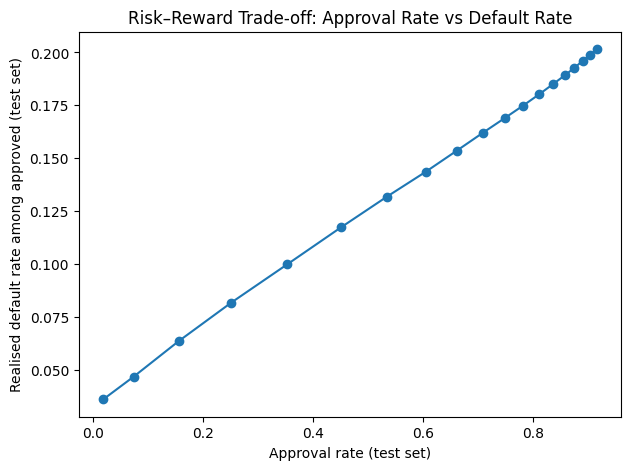

In [27]:
# Plot approval rate vs realised default rate (test)
plt.figure(figsize=(7, 5))
plt.plot(curve["approval_rate"], curve["realised_default_rate"], marker="o")
plt.xlabel("Approval rate (test set)")
plt.ylabel("Realised default rate among approved (test set)")
plt.title("Risk–Reward Trade-off: Approval Rate vs Default Rate")
plt.show()

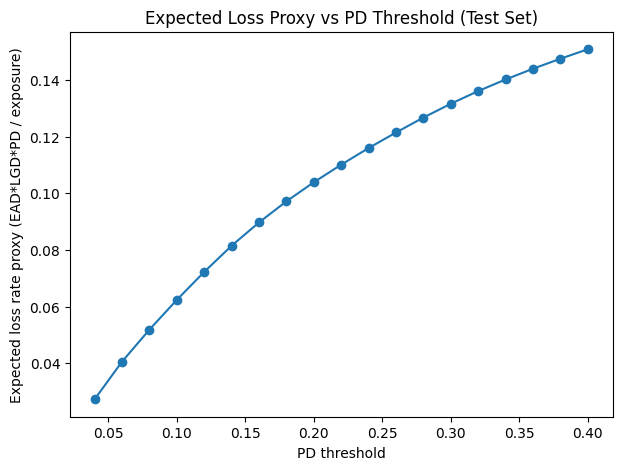

In [28]:
# Plot PD threshold vs expected loss rate proxy
plt.figure(figsize=(7, 5))
plt.plot(curve["pd_threshold"], curve["expected_loss_rate_proxy"], marker="o")
plt.xlabel("PD threshold")
plt.ylabel("Expected loss rate proxy (EAD*LGD*PD / exposure)")
plt.title("Expected Loss Proxy vs PD Threshold (Test Set)")
plt.show()

## 3) Define PD-based policies (risk appetites)
These mirror earlier grade policies, but they’re **loan-level**.


In [19]:
pd_policies = pd.DataFrame({
    "policy_name": ["pd_conservative", "pd_balanced", "pd_growth"],
    "pd_threshold": [0.10, 0.15, 0.20],
    "lgd_assumption": [LGD, LGD, LGD],
})
pd_policies

,policy_name,pd_threshold,lgd_assumption
0,pd_conservative,0.10,0.9
1,pd_balanced,0.15,0.9
2,pd_growth,0.20,0.9


## 4) Evaluate PD policies on the test set

In [20]:
def eval_pd_policy(df: pd.DataFrame, policy_name: str, thr: float, lgd: float) -> dict:
    approved = df[df["pd_pred"] < thr]
    approved_exposure = approved["exposure"].sum()
    exp_defaults = approved["pd_pred"].sum()
    exp_loss = (approved["exposure"] * lgd * approved["pd_pred"]).sum()

    return {
        "policy_name": policy_name,
        "pd_threshold": thr,
        "approved_loans": len(approved),
        "approval_rate": len(approved) / len(df),
        "approved_exposure": approved_exposure,
        "approved_avg_loan": approved["exposure"].mean(),
        "approved_avg_rate": approved["int_rate_pct"].mean(),
        "avg_pd_approved": approved["pd_pred"].mean(),
        "expected_defaults": exp_defaults,
        "expected_default_rate": approved["pd_pred"].mean(),
        "expected_loss_proxy": exp_loss,
        "expected_loss_rate_proxy": exp_loss / approved_exposure if approved_exposure > 0 else np.nan,
        "realised_defaults": approved["is_default"].sum(),
        "realised_default_rate": approved["is_default"].mean(),
    }

pd_policy_results = pd.DataFrame([
    eval_pd_policy(scored, r.policy_name, r.pd_threshold, r.lgd_assumption)
    for r in pd_policies.itertuples(index=False)
])

pd_policy_results.sort_values("pd_threshold")

,policy_name,pd_threshold,approved_loans,approval_rate,approved_exposure,approved_avg_loan,approved_avg_rate,avg_pd_approved,expected_defaults,expected_default_rate,expected_loss_proxy,expected_loss_rate_proxy,realised_defaults,realised_default_rate
0,pd_conservative,0.10,130417,0.251409,1.771961e+09,13586.886871,8.086764,0.070799,9233.447217,0.070799,1.105247e+08,0.062374,10667,0.081791
1,pd_balanced,0.15,256391,0.494253,3.346751e+09,13053.308716,9.661601,0.097087,24892.250147,0.097087,2.868003e+08,0.085695,32025,0.124907
2,pd_growth,0.20,343191,0.661581,4.513492e+09,13151.545859,10.649473,0.116258,39898.611698,0.116258,4.688322e+08,0.103874,52718,0.153611


## 5) Compare vs grade-based policies (test set)
compute grade cut-offs on the same scored test population for a fair comparison.

In [21]:
grade_rank = {g: i for i, g in enumerate(list("ABCDEFG"), start=1)}
scored["grade_rank"] = scored["grade"].map(grade_rank)

grade_policies = pd.DataFrame({
    "policy_name": ["grade_conservative", "grade_balanced", "grade_growth"],
    "max_grade_inclusive": ["B", "C", "D"],
})
grade_policies["max_grade_rank"] = grade_policies["max_grade_inclusive"].map(grade_rank)
grade_policies

,policy_name,max_grade_inclusive,max_grade_rank
0,grade_conservative,B,2
1,grade_balanced,C,3
2,grade_growth,D,4


In [22]:
def eval_grade_policy(df: pd.DataFrame, policy_name: str, max_rank: int, lgd: float) -> dict:
    approved = df[df["grade_rank"] <= max_rank]
    approved_exposure = approved["exposure"].sum()

    exp_defaults = approved["pd_pred"].sum()
    exp_loss = (approved["exposure"] * lgd * approved["pd_pred"]).sum()

    return {
        "policy_name": policy_name,
        "rule": f"grade_rank <= {max_rank}",
        "approved_loans": len(approved),
        "approval_rate": len(approved) / len(df),
        "approved_exposure": approved_exposure,
        "approved_avg_loan": approved["exposure"].mean(),
        "approved_avg_rate": approved["int_rate_pct"].mean(),
        "avg_pd_approved": approved["pd_pred"].mean(),
        "expected_defaults": exp_defaults,
        "expected_default_rate": approved["pd_pred"].mean(),
        "expected_loss_proxy": exp_loss,
        "expected_loss_rate_proxy": exp_loss / approved_exposure if approved_exposure > 0 else np.nan,
        "realised_defaults": approved["is_default"].sum(),
        "realised_default_rate": approved["is_default"].mean(),
    }

grade_policy_results = pd.DataFrame([
    eval_grade_policy(scored, r.policy_name, int(r.max_grade_rank), LGD)
    for r in grade_policies.itertuples(index=False)
])

grade_policy_results

,policy_name,rule,approved_loans,approval_rate,approved_exposure,approved_avg_loan,approved_avg_rate,avg_pd_approved,expected_defaults,expected_default_rate,expected_loss_proxy,expected_loss_rate_proxy,realised_defaults,realised_default_rate
0,grade_conservative,grade_rank <= 2,239902,0.462467,3.207584e+09,13370.394369,9.103674,0.101554,24363.026726,0.101554,2.959431e+08,0.092264,29564,0.123234
1,grade_balanced,grade_rank <= 3,396362,0.764080,5.469217e+09,13798.539530,11.042966,0.137876,54648.795947,0.137876,7.090112e+08,0.129637,69349,0.174964
2,grade_growth,grade_rank <= 4,471326,0.908591,6.644259e+09,14096.949670,12.237909,0.162225,76460.730565,0.162225,1.030329e+09,0.155071,94974,0.201504


In [23]:
comparison = pd.concat([pd_policy_results, grade_policy_results], ignore_index=True)
comparison = comparison.sort_values(["approval_rate", "policy_name"]).reset_index(drop=True)
comparison

,policy_name,pd_threshold,approved_loans,approval_rate,approved_exposure,approved_avg_loan,approved_avg_rate,avg_pd_approved,expected_defaults,expected_default_rate,expected_loss_proxy,expected_loss_rate_proxy,realised_defaults,realised_default_rate,rule
0,pd_conservative,0.10,130417,0.251409,1.771961e+09,13586.886871,8.086764,0.070799,9233.447217,0.070799,1.105247e+08,0.062374,10667,0.081791,NaN
1,grade_conservative,NaN,239902,0.462467,3.207584e+09,13370.394369,9.103674,0.101554,24363.026726,0.101554,2.959431e+08,0.092264,29564,0.123234,grade_rank <= 2
2,pd_balanced,0.15,256391,0.494253,3.346751e+09,13053.308716,9.661601,0.097087,24892.250147,0.097087,2.868003e+08,0.085695,32025,0.124907,NaN
3,pd_growth,0.20,343191,0.661581,4.513492e+09,13151.545859,10.649473,0.116258,39898.611698,0.116258,4.688322e+08,0.103874,52718,0.153611,NaN
4,grade_balanced,NaN,396362,0.764080,5.469217e+09,13798.539530,11.042966,0.137876,54648.795947,0.137876,7.090112e+08,0.129637,69349,0.174964,grade_rank <= 3
5,grade_growth,NaN,471326,0.908591,6.644259e+09,14096.949670,12.237909,0.162225,76460.730565,0.162225,1.030329e+09,0.155071,94974,0.201504,grade_rank <= 4


### visual: approval rate vs realised default rate
This shows which family of policies sits on a better risk frontier.

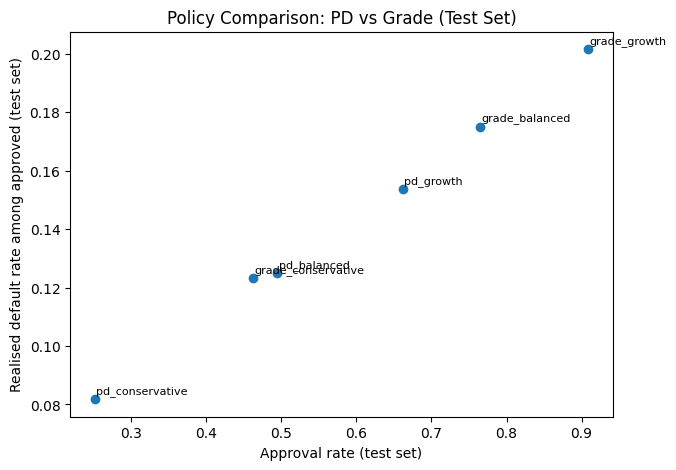

In [24]:
plt.figure(figsize=(7, 5))
plt.scatter(comparison["approval_rate"], comparison["realised_default_rate"])

for _, r in comparison.iterrows():
    plt.text(r["approval_rate"] + 0.002, r["realised_default_rate"] + 0.002, r["policy_name"], fontsize=8)

plt.xlabel("Approval rate (test set)")
plt.ylabel("Realised default rate among approved (test set)")
plt.title("Policy Comparison: PD vs Grade (Test Set)")
plt.show()


## 6) Save simulation artefacts

In [25]:
OUT_DIR = PROJECT_ROOT / "data" / "simulation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

curve.to_csv(OUT_DIR / "pd_threshold_curve_test.csv", index=False)
comparison.to_csv(OUT_DIR / "pd_policy_comparison_test.csv", index=False)

OUT_DIR

PosixPath('/home/jovyan/Home/notebooks/data/simulation')